<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/Week%205/batchnorm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 — Batch Normalization From Scratch

**Goal:** Build batch normalization by hand, then show how it makes neural networks train faster and more stably.

As data flows through a deep network, each layer's activations can drift to very different scales — which makes gradients unstable and slows training. **Batch normalization** fixes this by normalizing each layer's activations to mean 0 / std 1 across the batch, then applying a *learnable* scale and shift so the network keeps full expressive power.

### The forward pass, in four steps
For a batch $x$ (shape: batch × features), normalizing **per feature across the batch**:
$$\mu = \text{mean}(x), \quad \sigma^2 = \text{var}(x)$$
$$\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$$
$$y = \gamma \hat{x} + \beta$$

where $\gamma$ (scale) and $\beta$ (shift) are **learned**. Starting them at 1 and 0 means batchnorm begins as pure normalization and adapts from there.

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms

%matplotlib inline

## 1. BatchNorm From Scratch (NumPy)

The implementation mirrors the four-step formula, with one addition for **test time**.

**Train vs eval — the subtle part.** During training we normalize using *this batch's* mean and variance. But at test time we might have only one example, with no batch to compute statistics from. So during training we also keep a **running average** of mean and variance (an exponential moving average — the same pattern as Adam's moments), and use those frozen values at test time.

Note `axis=0, keepdims=True`: statistics are computed *down the batch axis*, giving one value per feature — the same axis pattern used in softmax and the Dense layer's bias gradient.

In [2]:
class BatchNorm:
  def __init__(self, num_features, momentum=0.9, eps=1e-5):
    self.momentum = momentum
    self.eps = eps

    # Learnable parameters: gamma=1, beta=0 -> starts as pure normalization
    self.gamma = np.ones((1, num_features))
    self.beta = np.zeros((1, num_features))

    # Running stats for test time (updated during training)
    self.running_mean = np.zeros((1, num_features))
    self.running_var = np.ones((1, num_features))

  def forward(self, x, training=True):
    if training:
      # 1. Batch statistics (over the batch axis)
      batch_mean = np.mean(x, axis=0, keepdims=True)
      batch_var = np.var(x, axis=0, keepdims=True)

      # 2. Normalize using this batch's stats
      x_norm = (x - batch_mean) / np.sqrt(batch_var + self.eps)

      # 3. Update running stats for later (test time) - exponential moving average
      self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * batch_mean
      self.running_var = self.momentum * self.running_var + (1 - self.momentum) * batch_var

    else:
      # Test time: use frozen running stats
      x_norm = (x - self.running_mean) / np.sqrt(self.running_var + self.eps)

    # 4. Scale and shift (same in both modes)
    out = self.gamma * x_norm + self.beta
    return out

**Test:** feed in data with mean ~3 and std ~10. Since $\gamma=1, \beta=0$, the output should come out normalized — mean ~0, std ~1 per feature.

In [3]:
bn = BatchNorm(num_features=5)
x = np.random.randn(32, 5) * 10 + 3    # batch of 32, mean ~3, std ~10
out = bn.forward(x, training=True)
print(f"Output mean of each feature: {out.mean(axis=0).round(3)}")   # ~0
print(f"Output std of each feature:  {out.std(axis=0).round(3)}")    # ~1

Output mean of each feature: [-0.  0. -0. -0.  0.]
Output std of each feature:  [1. 1. 1. 1. 1.]


Mean ~0, std ~1 across every feature — the normalization works.

### Why the learnable γ and β?
If we only ever forced mean 0 / std 1, we'd constrain what each layer can represent. The learnable scale $\gamma$ and shift $\beta$ let the network rescale and re-center the normalized values however it likes — even undoing the normalization entirely if that's optimal. So batchnorm stabilizes training **without** costing representational power.

---
## 2. Does It Help? — MNIST With vs Without BatchNorm

Two identical networks (784 → 256 → 256 → 10), the only difference being `nn.BatchNorm1d` after each linear layer. We'll train both and compare.

In [4]:
class PlainNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256), nn.ReLU(),
        nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, 10)
    )
  def forward(self, x):
    return self.net(x)


class BNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(),
        nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(),
        nn.Linear(256, 10)
    )
  def forward(self, x):
    return self.net(x)

In [5]:
transform = transforms.Compose([transforms.ToTensor()])

train = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_dataloader = DataLoader(train, batch_size=256, shuffle=True)
test_dataloader  = DataLoader(test,  batch_size=256, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.46MB/s]


In [6]:
def quick_train(model, lr, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for images, labels in train_dataloader:
            optimizer.zero_grad()
            out = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            running += loss.item()
        avg = running / len(train_dataloader)
        losses.append(avg)
        print(f"  epoch {epoch+1}: loss {avg:.4f}")
    return losses

### Experiment A — a low learning rate (0.01)

At a small learning rate, a plain network learns *slowly* — the update steps are tiny. Watch how batchnorm learns far faster in the same number of epochs.

In [7]:
print("Plain net at lr=0.01:")
plain_losses = quick_train(PlainNet(), lr=0.01)

print("\nBatchNorm net at lr=0.01:")
bn_losses = quick_train(BNet(), lr=0.01)

Plain net at lr=0.01:
  epoch 1: loss 2.2569
  epoch 2: loss 2.0323
  epoch 3: loss 1.4375
  epoch 4: loss 0.9065
  epoch 5: loss 0.6655

BatchNorm net at lr=0.01:
  epoch 1: loss 0.7716
  epoch 2: loss 0.3270
  epoch 3: loss 0.2450
  epoch 4: loss 0.2021
  epoch 5: loss 0.1739


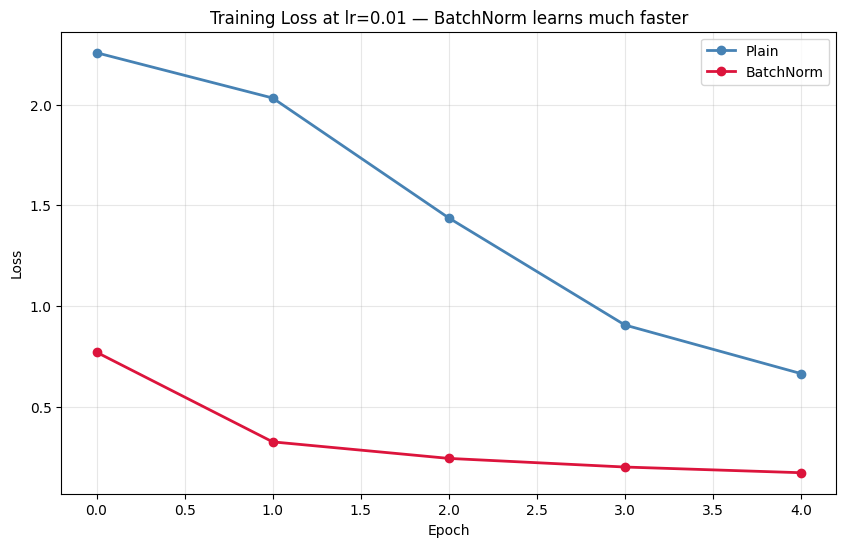

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(plain_losses, label='Plain', color='steelblue', lw=2, marker='o')
plt.plot(bn_losses,   label='BatchNorm', color='crimson', lw=2, marker='o')
plt.title('Training Loss at lr=0.01 — BatchNorm learns much faster')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Typical result:** the plain net barely moves (loss still ~0.6 after 5 epochs, starting near the random-guess 2.3), while batchnorm drops to ~0.18. Batchnorm's normalized activations let the network make real progress even when the learning rate is small.

### Experiment B — a high learning rate (0.8)

At a large learning rate, both can train, but batchnorm stays ahead — converging faster and reaching a lower loss. Batchnorm widens the range of learning rates that work well.

In [9]:
print("Plain net at lr=0.8:")
plain_hi = quick_train(PlainNet(), lr=0.8)

print("\nBatchNorm net at lr=0.8:")
bn_hi = quick_train(BNet(), lr=0.8)

Plain net at lr=0.8:
  epoch 1: loss 0.5644
  epoch 2: loss 0.1395
  epoch 3: loss 0.0956
  epoch 4: loss 0.0676
  epoch 5: loss 0.0547

BatchNorm net at lr=0.8:
  epoch 1: loss 0.2017
  epoch 2: loss 0.0741
  epoch 3: loss 0.0458
  epoch 4: loss 0.0303
  epoch 5: loss 0.0227


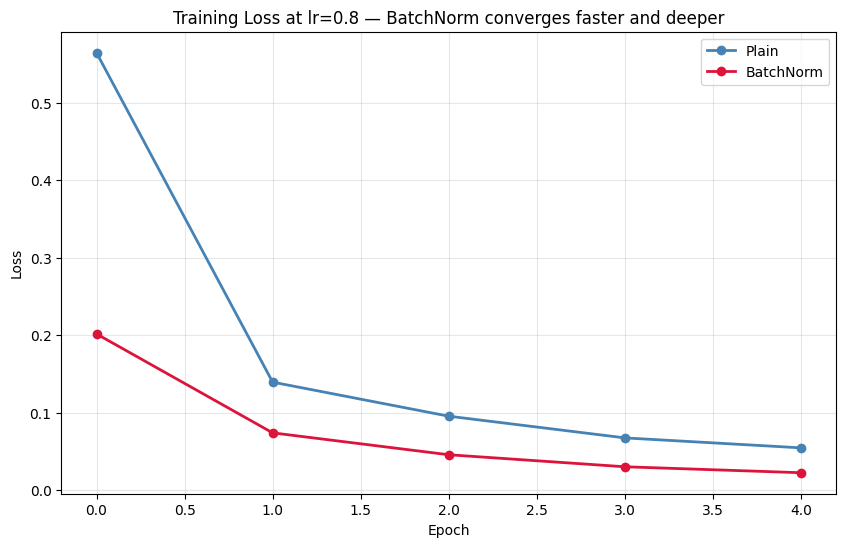

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(plain_hi, label='Plain', color='steelblue', lw=2, marker='o')
plt.plot(bn_hi,   label='BatchNorm', color='crimson', lw=2, marker='o')
plt.title('Training Loss at lr=0.8 — BatchNorm converges faster and deeper')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

---
## Summary

| Piece | What it does |
|---|---|
| Normalize | $(x-\mu)/\sqrt{\sigma^2+\epsilon}$ per feature, across the batch |
| Learnable $\gamma, \beta$ | scale + shift, so no representational power is lost |
| Running stats | EMA of mean/var, frozen for test time |

**What we saw:** across both low and high learning rates, the batchnorm network trained **faster** and reached a **lower loss** than the plain network. By keeping activations at a stable scale, batchnorm makes training less sensitive to the learning rate and lets networks learn more quickly — which is why it became a standard component of deep networks.

**A note for later:** Transformers use *Layer* Normalization (normalizing across features instead of across the batch) — same normalize-then-scale-shift idea, different axis. You'll meet it in Week 9.

---
PyTorch + autograd · MNIST in PyTorch · SGD/momentum/Adam from scratch · dropout + weight decay · batch normalization. **Next: — Convolutional Neural Networks on CIFAR-10.**